In [35]:
# Standard Library
import os
import re
from pathlib import Path
from datetime import datetime

# Numerical / Data
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import matplotlib as mpl

# Geospatial
import geopandas as gpd
from shapely.geometry import Point

# Stats / Analysis
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit
from scipy.stats import ttest_ind
from statsmodels.nonparametric.smoothers_lowess import lowess

from io import StringIO
import re


# Read Dataset

In [36]:
df_coastsat = pd.read_csv('oahu0012_intersects_outliersremoved_COASTSAT.csv')
# df_coastsat['dates'] = pd.to_datetime(df_coastsat['dates'])
# df_coastsat['dates'] = df_coastsat['dates'].dt.tz_convert('Pacific/Honolulu')

# 1. Load the shapefile
shapefile_path = r"C:\Users\bgorberg\Documents\Erosion_Planet\CRC_dataset\shapefiles\NS_transects.shp"
gdf = gpd.read_file(shapefile_path)

df_coastsat['dates'] = (
    pd.to_datetime(df_coastsat['dates'])                 # make sure it's datetime                     # tell pandas this is UTC time
    .dt.tz_convert('Pacific/Honolulu')          # convert to Hawaii Standard Time
)
df_coastsat["type"] = "UNKNOWN"

df_coastsat.loc[df_coastsat["satname"].str.startswith("L"), "type"] = "LANDSAT"
df_coastsat.loc[df_coastsat["satname"].str.startswith("S"), "type"] = "SENTINEL"
#df_coastsat = df_coastsat.drop(columns=['satname'])
df_coastsat = df_coastsat.set_index('dates')




df_planet = pd.read_csv('oahu0012_intersects_outliersremoved_PLANET.csv')
df_planet['dates'] = (
    pd.to_datetime(df_planet['dates'])                 # make sure it's datetime
    .dt.tz_localize('UTC')                      # tell pandas this is UTC time
    .dt.tz_convert('Pacific/Honolulu')          # convert to Hawaii Standard Time
)
df_planet['type'] = 'PLANET'
df_planet = df_planet.rename(columns=lambda c: re.sub(r'^(?:oahu)+_?', 'oahu', c))
df_planet = df_planet.set_index('dates')




merged_planet_coast = pd.concat([df_coastsat, df_planet])  # or drop ignore_index to keep original index
merged_planet_coast = merged_planet_coast.sort_index()

# Apply BIAS

In [37]:

# ----------------------------------------------------
# Ensure datetime index
# ----------------------------------------------------

# --- Recompute overall means (2016-12-31 onward) ---
start_date = pd.Timestamp("2016-12-31").tz_localize(merged_planet_coast.index.tz)
df_filtered = merged_planet_coast.loc[start_date:]
df_filtered.index = pd.to_datetime(df_filtered.index)
df_filtered = df_filtered.sort_index()

# ----------------------------------------------------
# Identify transect columns
# ----------------------------------------------------
transect_cols = [col for col in df_filtered.columns if col.startswith("oahu")]

# ----------------------------------------------------
# Split by satellite type
# ----------------------------------------------------
planet_df = df_filtered[df_filtered["type"] == "PLANET"][transect_cols]
landsat_df = df_filtered[df_filtered["type"] == "LANDSAT"][transect_cols]
sentinel_df = df_filtered[df_filtered["type"] == "SENTINEL"][transect_cols]

# ----------------------------------------------------
# Resample to monthly means
# ----------------------------------------------------
planet_monthly = planet_df.resample("M").mean()
landsat_monthly = landsat_df.resample("M").mean()
sentinel_monthly = sentinel_df.resample("M").mean()

# ----------------------------------------------------
# Compute mean of monthly values (equal monthly weighting)
# ----------------------------------------------------
planet_mean = planet_monthly.mean()
landsat_mean = landsat_monthly.mean()
sentinel_mean = sentinel_monthly.mean()

# ----------------------------------------------------
# Build bias dataframe
# ----------------------------------------------------
bias_monthly_df = pd.DataFrame({
    "transect": transect_cols,
    "planet_monthly_mean": planet_mean.values,
    "landsat_monthly_mean": landsat_mean.values,
    "sentinel_monthly_mean": sentinel_mean.values,
})

bias_monthly_df["planet_minus_landsat"] = (
    bias_monthly_df["planet_monthly_mean"]
    - bias_monthly_df["landsat_monthly_mean"]
)

bias_monthly_df["planet_minus_sentinel"] = (
    bias_monthly_df["planet_monthly_mean"]
    - bias_monthly_df["sentinel_monthly_mean"]
)

bias_monthly_df

C:\Users\bgorberg\AppData\Local\Temp\ipykernel_2744\671262513.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  planet_monthly = planet_df.resample("M").mean()
C:\Users\bgorberg\AppData\Local\Temp\ipykernel_2744\671262513.py:27: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  landsat_monthly = landsat_df.resample("M").mean()
C:\Users\bgorberg\AppData\Local\Temp\ipykernel_2744\671262513.py:28: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sentinel_monthly = sentinel_df.resample("M").mean()


,transect,planet_monthly_mean,landsat_monthly_mean,sentinel_monthly_mean,planet_minus_landsat,planet_minus_sentinel
0,oahu0012_0001,96.144257,89.421134,85.337829,6.723122,10.806428
1,oahu0012_0002,91.870014,77.631074,72.663276,14.238940,19.206738
2,oahu0012_0003,97.581785,81.854386,77.688703,15.727399,19.893082
3,oahu0012_0004,103.598420,90.947056,86.126773,12.651364,17.471647
4,oahu0012_0005,101.032097,89.536218,83.058791,11.495879,17.973307
...,...,...,...,...,...,...
241,oahu0012_0242,17.512850,14.510383,7.271689,3.002467,10.241161
242,oahu0012_0243,17.030348,19.866683,11.642866,-2.836335,5.387482
243,oahu0012_0244,21.484675,27.391459,17.623625,-5.906784,3.861050
244,oahu0012_0245,24.792570,30.253337,19.647971,-5.460767,5.144599


In [38]:
# --- Copy original dataset ---
merged_corrected = merged_planet_coast.copy()

# --- Identify transect columns ---
transect_cols = [col for col in merged_corrected.columns if col.startswith("oahu")]


satellite_means = (
    df_filtered
    .groupby("type")[transect_cols]
    .mean()
    .mean(axis=1)
)

# --------------------------------------------
# Copy dataset to preserve original
# --------------------------------------------
merged_corrected = merged_planet_coast.copy()

# Identify transect columns
transect_cols = bias_monthly_df["transect"].values

# --------------------------------------------
# Apply transect-by-transect correction
# --------------------------------------------
for _, row in bias_monthly_df.iterrows():
    
    transect = row["transect"]
    
    bias_ls = row["planet_minus_landsat"]
    bias_sn = row["planet_minus_sentinel"]
    
    # Correct LANDSAT
    merged_corrected.loc[
        merged_corrected["type"] == "LANDSAT",
        transect
    ] += bias_ls
    
    # Correct SENTINEL
    merged_corrected.loc[
        merged_corrected["type"] == "SENTINEL",
        transect
    ] += bias_sn

print("Per-transect monthly bias correction applied.")

Per-transect monthly bias correction applied.


# Read updated Planet Data

In [39]:
df_updated = pd.read_csv(os.path.join("NS-oahu0012-update", "oahu0012_intersects_outliersremoved_clean.csv"))
df_updated['timestamp'] = (
    pd.to_datetime(df_updated['timestamp'])                 # make sure it's datetime
    .dt.tz_localize('UTC')                      # tell pandas this is UTC time
    .dt.tz_convert('Pacific/Honolulu')          # convert to Hawaii Standard Time
)
df_updated = df_updated.set_index("timestamp")

In [40]:
# Ensure both are sorted
merged_planet_coast = merged_corrected.copy().sort_index()
df_updated = df_updated.sort_index()

# Get last timestamp from original dataframe
last_date = merged_planet_coast.index.max()

# Keep only newer rows from df_updated
df_updated_new = df_updated.loc[df_updated.index > last_date]

# Concatenate
merged_final = pd.concat([merged_planet_coast, df_updated_new]).sort_index()

# Resampling

In [41]:
#use the mean bias corrected dataset with the updated datza
merged_final.index = pd.to_datetime(merged_final.index)
# keep only numeric columns
numeric_df = merged_final.select_dtypes(include='number')

#have to use averages instead of medians
monthly_avg = numeric_df.resample('ME').mean()


# Read MEI / ONI

In [42]:
file_path = "Raw_Climate_Index/meiv2.data"

# Read all lines
with open(file_path, "r") as f:
    lines = f.readlines()

# Keep only valid data lines (start with 4-digit year and contain at least 13 numeric values)
pattern = re.compile(r'^\s*\d{4}\s+')
data_lines = [line.strip() for line in lines if pattern.match(line) and len(line.split()) >= 13]

# Join the lines into a single string
data_str = "\n".join(data_lines)

# Read into DataFrame
df = pd.read_csv(StringIO(data_str), sep=r"\s+", header=None)

# Assign column names (Year + 12 months)
df.columns = ["Year", "Jan", "Feb", "Mar", "Apr", "May", "Jun",
              "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Convert data to numeric safely
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Convert to long format with datetime index
df_long = df.melt(id_vars="Year", var_name="Month", value_name="MEI")
df_long["Date"] = pd.to_datetime(df_long["Year"].astype(str) + df_long["Month"], format="%Y%b")
df_long = df_long[["Date", "MEI"]].sort_values("Date").reset_index(drop=True)

df_long['ENSO_MEI'] = np.nan
for i in range(len(df_long.MEI)):
    if df_long.MEI[i] >= 0.5:
        df_long.ENSO_MEI[i] = 'EL NINO'
    elif df_long.MEI[i] <= -0.5:
        df_long.ENSO_MEI[i] = 'LA NINA'
    else:
        df_long.ENSO_MEI[i] = 'NUETRAL'
    
MEI_dataset = df_long.copy()




# # Path to your uploaded ONI text file
# file_path = r"Raw_Climate_Index/oni.txt"

# # Read and clean the fixed-width formatted data
# df_oni = pd.read_csv(
#     file_path,
#     delim_whitespace=True,
#     skiprows=1,          # skip the header line "SEAS  YR   TOTAL   ANOM"
#     names=["SEAS", "YR", "TOTAL", "ANOM"],
#     na_values=["", " "]
# )

# # Drop any completely empty rows
# df_oni = df_oni.dropna(subset=["SEAS", "YR", "ANOM"])

# # Create a datetime column — season midpoint (approx)
# # We'll use the year and the season's middle month
# month_map = {
#     "DJF": 1, "JFM": 2, "FMA": 3, "MAM": 4, "AMJ": 5, "MJJ": 6,
#     "JJA": 7, "JAS": 8, "ASO": 9, "SON": 10, "OND": 11, "NDJ": 12
# }
# df_oni["month"] = df_oni["SEAS"].map(month_map)
# df_oni["date"] = pd.to_datetime(df_oni["YR"].astype(int).astype(str) + "-" + df_oni["month"].astype(str) + "-15")

# # Reorder columns for clarity
# df_oni = df_oni[["date", "SEAS", "YR", "TOTAL", "ANOM"]]

# # ---- 3️⃣ Apply NOAA’s 5 overlapping 3-month rule ----
# EL_NINO = 0.5
# LA_NINA = -0.5
# WINDOW = 5

# oni_values = df_oni["ANOM"].values
# phase = np.array(["NUETRAL"] * len(oni_values), dtype=object)

# # --- El Niño detection ---
# count = 0
# for i in range(len(oni_values)):
#     if oni_values[i] >= EL_NINO:
#         count += 1
#     else:
#         count = 0
#     if count >= WINDOW:
#         phase[i - WINDOW + 1 : i + 1] = "EL NINO"

# # --- La Niña detection ---
# count = 0
# for i in range(len(oni_values)):
#     if oni_values[i] <= LA_NINA:
#         count += 1
#     else:
#         count = 0
#     if count >= WINDOW:
#         phase[i - WINDOW + 1 : i + 1] = "LA NINA"

# df_oni["ENSO_ONI"] = phase
# df_oni = df_oni.rename(columns={'ANOM': 'ONI'})

C:\Users\bgorberg\AppData\Local\Temp\ipykernel_2744\1402119185.py:37: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_long.ENSO_MEI[i] = 'NUETRAL'
C:\Users\bgorberg\AppData\Local\Temp\ipykernel_2744\1402119185.py:37: SettingWithCopyWarning:

# Classify ENSO Phase

In [43]:

# --- Clean dataset ---
MEI_dataset["Date"] = pd.to_datetime(MEI_dataset["Date"])
MEI_dataset["MEI"] = MEI_dataset["MEI"].replace(-999.00, np.nan)
MEI_dataset = MEI_dataset.sort_values("Date").reset_index(drop=True)

# --- Create ENSO year anchored on October ---
MEI_dataset["ENSO_year"] = np.where(
    MEI_dataset["Date"].dt.month >= 10,  # Oct, Nov, Dec
    MEI_dataset["Date"].dt.year,
    MEI_dataset["Date"].dt.year - 1      # Jan belongs to previous Oct year
)

# --- Keep only ONDJ months ---
ondj = MEI_dataset[MEI_dataset["Date"].dt.month.isin([11, 12, 1])].copy()

results = []

for year, group in ondj.groupby("ENSO_year"):
    
    # Ensure we have all 4 months if you care
    # if len(group) < 4:
    #     continue
    
    mean_mei = group["MEI"].mean()
    
    if np.isnan(mean_mei):
        continue
    
    if mean_mei > 0.5:
        direction = "NINO"
    elif mean_mei < -0.5:
        direction = "NINA"
    else:
        direction = "NEUTRAL"
    
    results.append({
        "Start_Date": pd.Timestamp(year, 9, 1),
        "End_Date": pd.Timestamp(year + 1, 8, 31),
        "ONDJ_mean_MEI": mean_mei,
        "ENSO_direction": direction
    })

enso_summary_df = (
    pd.DataFrame(results)
    .sort_values("Start_Date")
    .reset_index(drop=True)
)

enso_summary_df.head()

,Start_Date,End_Date,ONDJ_mean_MEI,ENSO_direction
0,1978-09-01,1979-08-31,0.460000,NEUTRAL
1,1979-09-01,1980-08-31,0.496667,NEUTRAL
2,1980-09-01,1981-08-31,-0.183333,NEUTRAL
3,1981-09-01,1982-08-31,-0.300000,NEUTRAL
4,1982-09-01,1983-08-31,2.320000,NINO


In [44]:
# Convert ENSO dates
enso_summary_df['Start_Date'] = pd.to_datetime(enso_summary_df['Start_Date']).dt.tz_localize(None)
enso_summary_df['End_Date']   = pd.to_datetime(enso_summary_df['End_Date']).dt.tz_localize(None)

# Convert monthly_avg index
monthly_avg.index = pd.to_datetime(monthly_avg.index).tz_localize(None)
enso_summary_df['interval'] = pd.IntervalIndex.from_arrays(
    enso_summary_df['Start_Date'],
    enso_summary_df['End_Date'],
    closed='both'
)

def get_enso_label(date):
    match = enso_summary_df.loc[enso_summary_df['interval'].apply(lambda x: date in x)]
    if not match.empty:
        return match['ENSO_direction'].iloc[0]
    return None

monthly_avg['ENSO_direction'] = monthly_avg.index.map(get_enso_label)

# Calculate anomalies and statistical signficance at each transect

In [45]:
# Drop ENSO column for mean calculation
transect_cols = monthly_avg.columns.drop("ENSO_direction")

neutral_df = monthly_avg[monthly_avg["ENSO_direction"] == "NEUTRAL"]

neutral_mean = neutral_df[transect_cols].mean()
anomalies = monthly_avg.copy()
anomalies[transect_cols] = anomalies[transect_cols] - neutral_mean
nina_anomalies = anomalies[anomalies["ENSO_direction"] == "NINA"]
nino_anomalies = anomalies[anomalies["ENSO_direction"] == "NINO"]

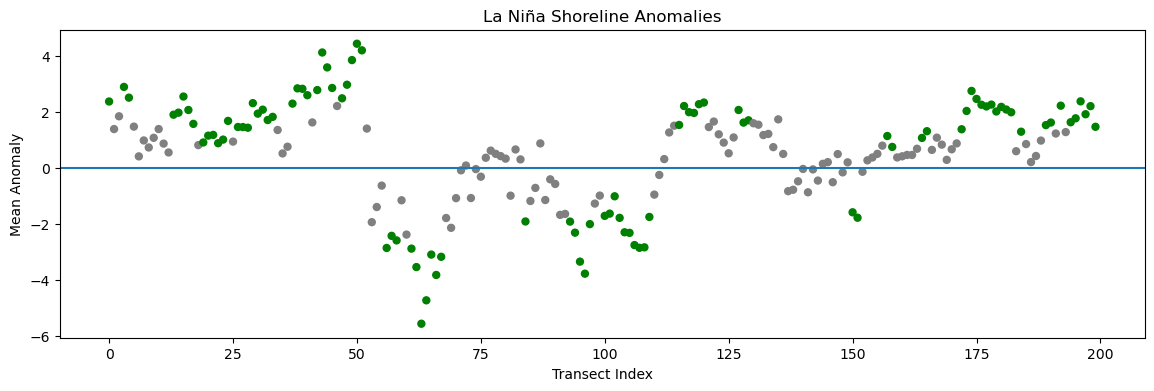

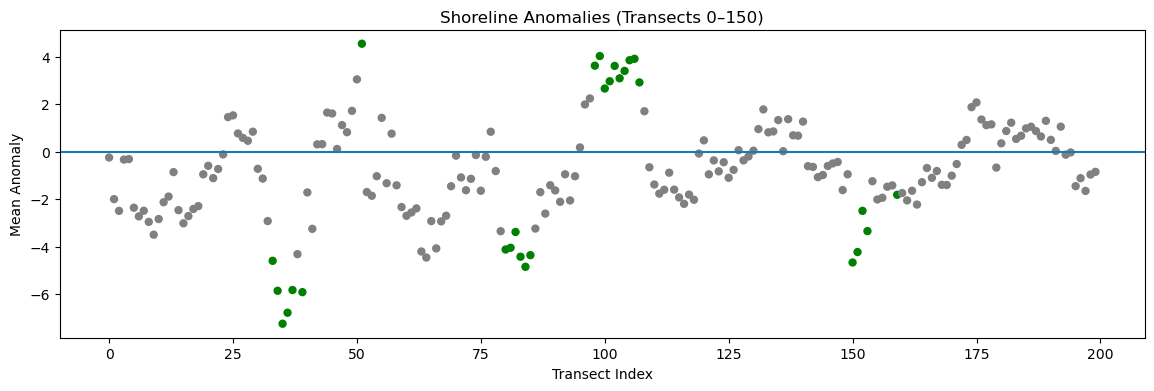

In [46]:
from scipy.stats import wilcoxon
results = []

for col in transect_cols:

    data = nina_anomalies[col].dropna()
    MEAN = data.mean()

    if len(data) > 5:

        stat, p = wilcoxon(data, alternative="greater")

        # determine significance
        if MEAN > 0:
            significance = 1 if p < 0.05 else 0

        elif MEAN < 0:
            significance = 1 if p > 0.95 else 0

        else:
            significance = 0

        results.append({
            "transect": col,
            "mean_anomaly": MEAN,
            "p_value": p,
            "n_samples": len(data),
            "significance": significance
        })

results_df = pd.DataFrame(results)

subset = results_df.iloc[0:200]   # transects 0–150

colors = subset["significance"].map({1: "green", 0: "gray"})

plt.figure(figsize=(14,4))

plt.scatter(
    range(len(subset)),
    subset["mean_anomaly"],
    c=colors,
    s=25
)

plt.axhline(0)

plt.xlabel("Transect Index")
plt.ylabel("Mean Anomaly")
plt.title("La Niña Shoreline Anomalies")

plt.show()
nina_results = results_df
results = []

for col in transect_cols:

    data = nino_anomalies[col].dropna()
    MEAN = data.mean()

    if len(data) > 5:

        stat, p = wilcoxon(data, alternative="greater")

        # determine significance
        if MEAN > 0:
            significance = 1 if p < 0.05 else 0

        elif MEAN < 0:
            significance = 1 if p > 0.95 else 0

        else:
            significance = 0

        results.append({
            "transect": col,
            "mean_anomaly": MEAN,
            "p_value": p,
            "n_samples": len(data),
            "significance": significance
        })

results_df = pd.DataFrame(results)

subset = results_df.iloc[0:200]   # transects 0–150

colors = subset["significance"].map({1: "green", 0: "gray"})

plt.figure(figsize=(14,4))

plt.scatter(
    range(len(subset)),
    subset["mean_anomaly"],
    c=colors,
    s=25
)

plt.axhline(0)

plt.xlabel("Transect Index")
plt.ylabel("Mean Anomaly")
plt.title("Shoreline Anomalies (Transects 0–150)")

plt.show()
nino_results = results_df


# Group Transects by seasonal cells and make figures for map

In [47]:
def clip_transects(df, start_transect, end_transect):

    df = df.copy()

    # extract numeric transect ID
    df["transect_id"] = df["transect"].str.extract(r'(\d+)$').astype(int)

    # clip range
    df_clipped = df[
        (df["transect_id"] >= start_transect) &
        (df["transect_id"] <= end_transect )
    ]

    return df_clipped.drop(columns="transect_id")

In [48]:
#0-52 keikis to ehukai
# 53-76 ehukai/pupukea
# 77-95 rockies
# 96-112 kammis/monstas
# 113-135 sunset
start_trans = [1,53,77,96,113]
end_trans = [52, 76, 95, 112]

### Nina

start = 1 end = 52


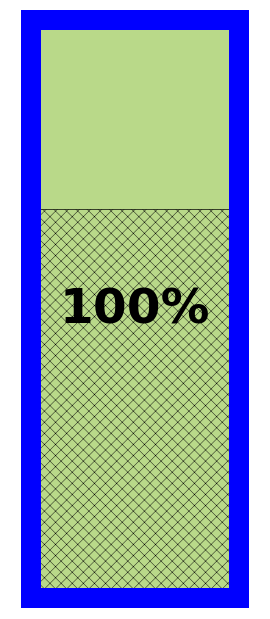

start = 53 end = 76


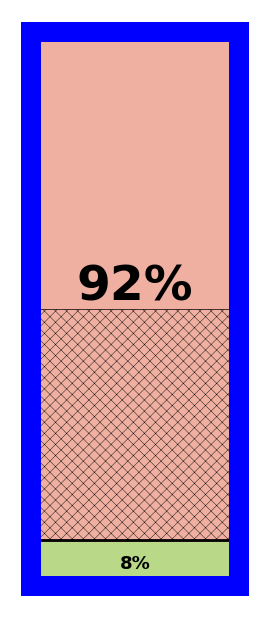

start = 77 end = 95


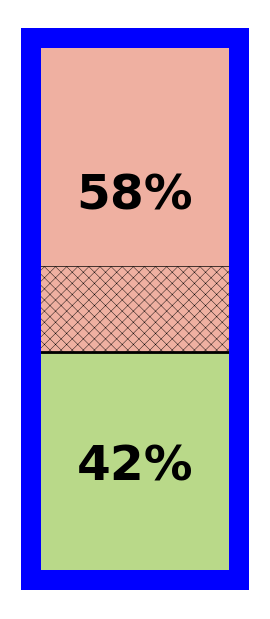

start = 96 end = 112


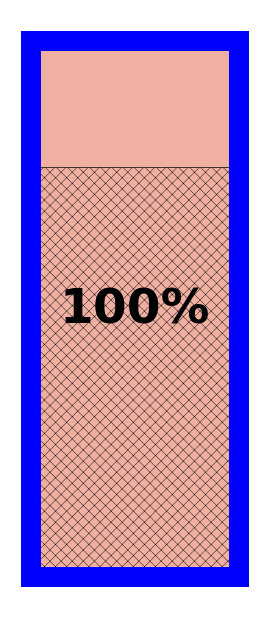

In [49]:
for start, end in zip(start_trans, end_trans):
    print("start =", start, "end =", end)
    start_transect = start
    end_transect = end
    clipped = clip_transects(df=nina_results, start_transect=start_transect, end_transect=end_transect)

    pos_total = (clipped["mean_anomaly"] > 0).sum()
    neg_total = (clipped["mean_anomaly"] < 0).sum()

    pos_sig = ((clipped["mean_anomaly"] > 0) &
               (clipped["significance"] == 1)).sum()

    neg_sig = ((clipped["mean_anomaly"] < 0) &
               (clipped["significance"] == 1)).sum()

    total = pos_total + neg_total
    pos_pct = 100 * pos_total / total
    neg_pct = 100 * neg_total / total

    mpl.rcParams["hatch.linewidth"] = 0.3

    fig, ax = plt.subplots(figsize=(2.5, 6))

    # make background transparent
    fig.patch.set_alpha(0)
    ax.set_facecolor("none")

    ax.bar([""], [pos_total],
           width=0.2,
           color="#b9d989",
           edgecolor="black",
           linewidth=1,
           alpha=1)

    ax.bar([""], [neg_total],
           bottom=[pos_total],
           width=0.2,
           color="#efb0a1",
           edgecolor="black",
           linewidth=2,
           alpha=1)

    ax.set_xlim(-0.12, 0.12)
    ax.margins(x=0)

    ax.bar([""], [pos_sig],
           width=0.2,
           color="none",
           edgecolor="black",
           hatch="xxx",
           linewidth=0.5)

    ax.bar([""], [neg_sig],
           width=0.2,
           bottom=[pos_total],
           color="none",
           edgecolor="black",
           hatch="xxx",
           linewidth=0.5)

    ax.set_ylabel("")
    ax.set_yticks([])
    ax.tick_params(axis="both", which="both", length=0)
    ax.set_xticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    if pos_pct != 0:
        pos_fontsize = 13 if pos_pct < 10 else 35
        ax.text(0, pos_total / 2, f"{round(pos_pct)}%",
                ha="center", va="center",
                fontsize=pos_fontsize, fontweight="bold", color="black")

    if neg_pct != 0:
        neg_fontsize = 13 if neg_pct < 10 else 35
        ax.text(0, pos_total + neg_total / 2, f"{round(neg_pct)}%",
                ha="center", va="center",
                fontsize=neg_fontsize, fontweight="bold", color="black")

    from matplotlib.patches import Rectangle
    outline_blue = Rectangle(
        (-0.1, 0), 0.2, pos_total + neg_total,
        fill=False, edgecolor="blue", linewidth=13,
        antialiased=False, joinstyle="miter"
    )
    ax.add_patch(outline_blue)

    ax.set_ylim(-1, pos_total + neg_total + 1)

    # remove outer padding completely
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

    plt.savefig(
        os.path.join("Brian_figs", f"nina_{start_transect}-{end_transect}.png"),
        dpi=300,
        transparent=True,
        bbox_inches="tight",
        pad_inches=0
    )
    plt.show()

### Nino

start = 1 end = 52


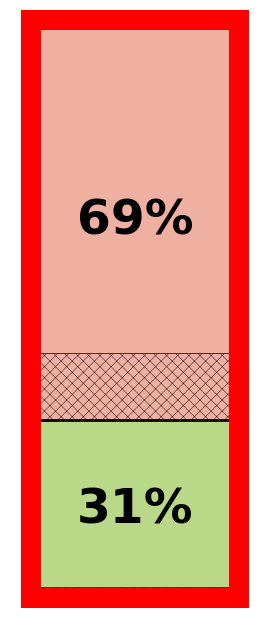

start = 53 end = 76


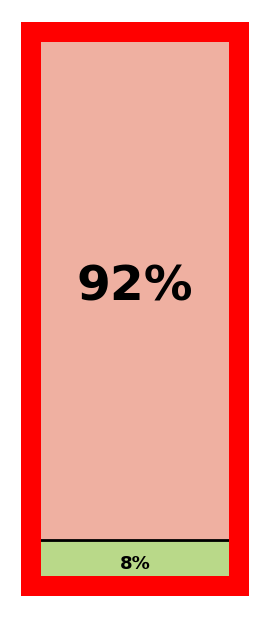

start = 77 end = 95


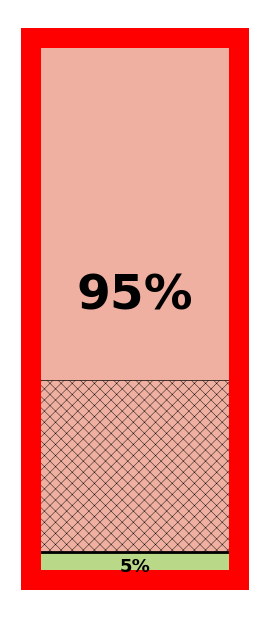

start = 96 end = 112


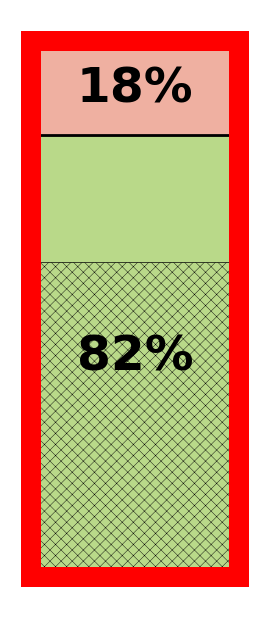

start = 113 end = 135


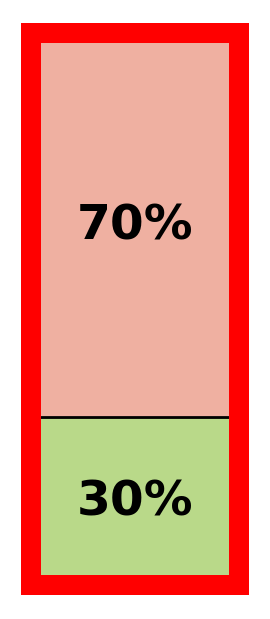

In [50]:
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

start_trans = [1, 53, 77, 96, 113]
end_trans   = [52, 76, 95, 112, 135]

for start, end in zip(start_trans, end_trans):
    print("start =", start, "end =", end)
    start_transect = start
    end_transect = end

    clipped = clip_transects(
        df=nino_results,
        start_transect=start_transect,
        end_transect=end_transect
    )

    pos_total = (clipped["mean_anomaly"] > 0).sum()
    neg_total = (clipped["mean_anomaly"] < 0).sum()

    pos_sig = ((clipped["mean_anomaly"] > 0) &
               (clipped["significance"] == 1)).sum()

    neg_sig = ((clipped["mean_anomaly"] < 0) &
               (clipped["significance"] == 1)).sum()

    total = pos_total + neg_total
    pos_pct = 100 * pos_total / total
    neg_pct = 100 * neg_total / total

    mpl.rcParams["hatch.linewidth"] = 0.3

    fig, ax = plt.subplots(figsize=(2.5, 6), facecolor="none")
    fig.patch.set_alpha(0)
    ax.set_facecolor("none")

    # bars
    ax.bar(
        [""], [pos_total],
        width=0.2,
        color="#b9d989",
        edgecolor="black",
        linewidth=1,
        alpha=1
    )

    ax.bar(
        [""], [neg_total],
        bottom=[pos_total],
        width=0.2,
        color="#efb0a1",
        edgecolor="black",
        linewidth=2,
        alpha=1
    )

    ax.set_xlim(-0.12, 0.12)
    ax.margins(x=0)

    # significant overlays
    ax.bar(
        [""], [pos_sig],
        width=0.2,
        color="none",
        edgecolor="black",
        hatch="xxx",
        linewidth=0.5
    )

    ax.bar(
        [""], [neg_sig],
        width=0.2,
        bottom=[pos_total],
        color="none",
        edgecolor="black",
        hatch="xxx",
        linewidth=0.5
    )

    ax.set_ylabel("")
    ax.set_yticks([])
    ax.set_xticks([])
    ax.tick_params(axis="both", which="both", length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    if pos_pct != 0:
        pos_fontsize = 13 if pos_pct < 10 else 35
        ax.text(
            0, pos_total / 2,
            f"{round(pos_pct)}%",
            ha="center",
            va="center",
            fontsize=pos_fontsize,
            fontweight="bold",
            color="black"
        )

    if neg_pct != 0:
        neg_fontsize = 13 if neg_pct < 10 else 35
        ax.text(
            0, pos_total + neg_total / 2,
            f"{round(neg_pct)}%",
            ha="center",
            va="center",
            fontsize=neg_fontsize,
            fontweight="bold",
            color="black"
        )

    outline_red = Rectangle(
        (-0.1, 0),
        0.2,
        pos_total + neg_total,
        fill=False,
        edgecolor="red",
        linewidth=13,
        antialiased=False,
        joinstyle="miter",
        clip_on=False
    )
    ax.add_patch(outline_red)

    ax.set_ylim(-1, pos_total + neg_total + 1)

    # remove all extra figure padding
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

    outpath = os.path.join(
        "Brian_figs",
        f"nino_{start_transect}-{end_transect}.png"
    )

    plt.savefig(
        outpath,
        dpi=300,
        transparent=True,
        pad_inches=0
    )
    plt.show()
    plt.close(fig)

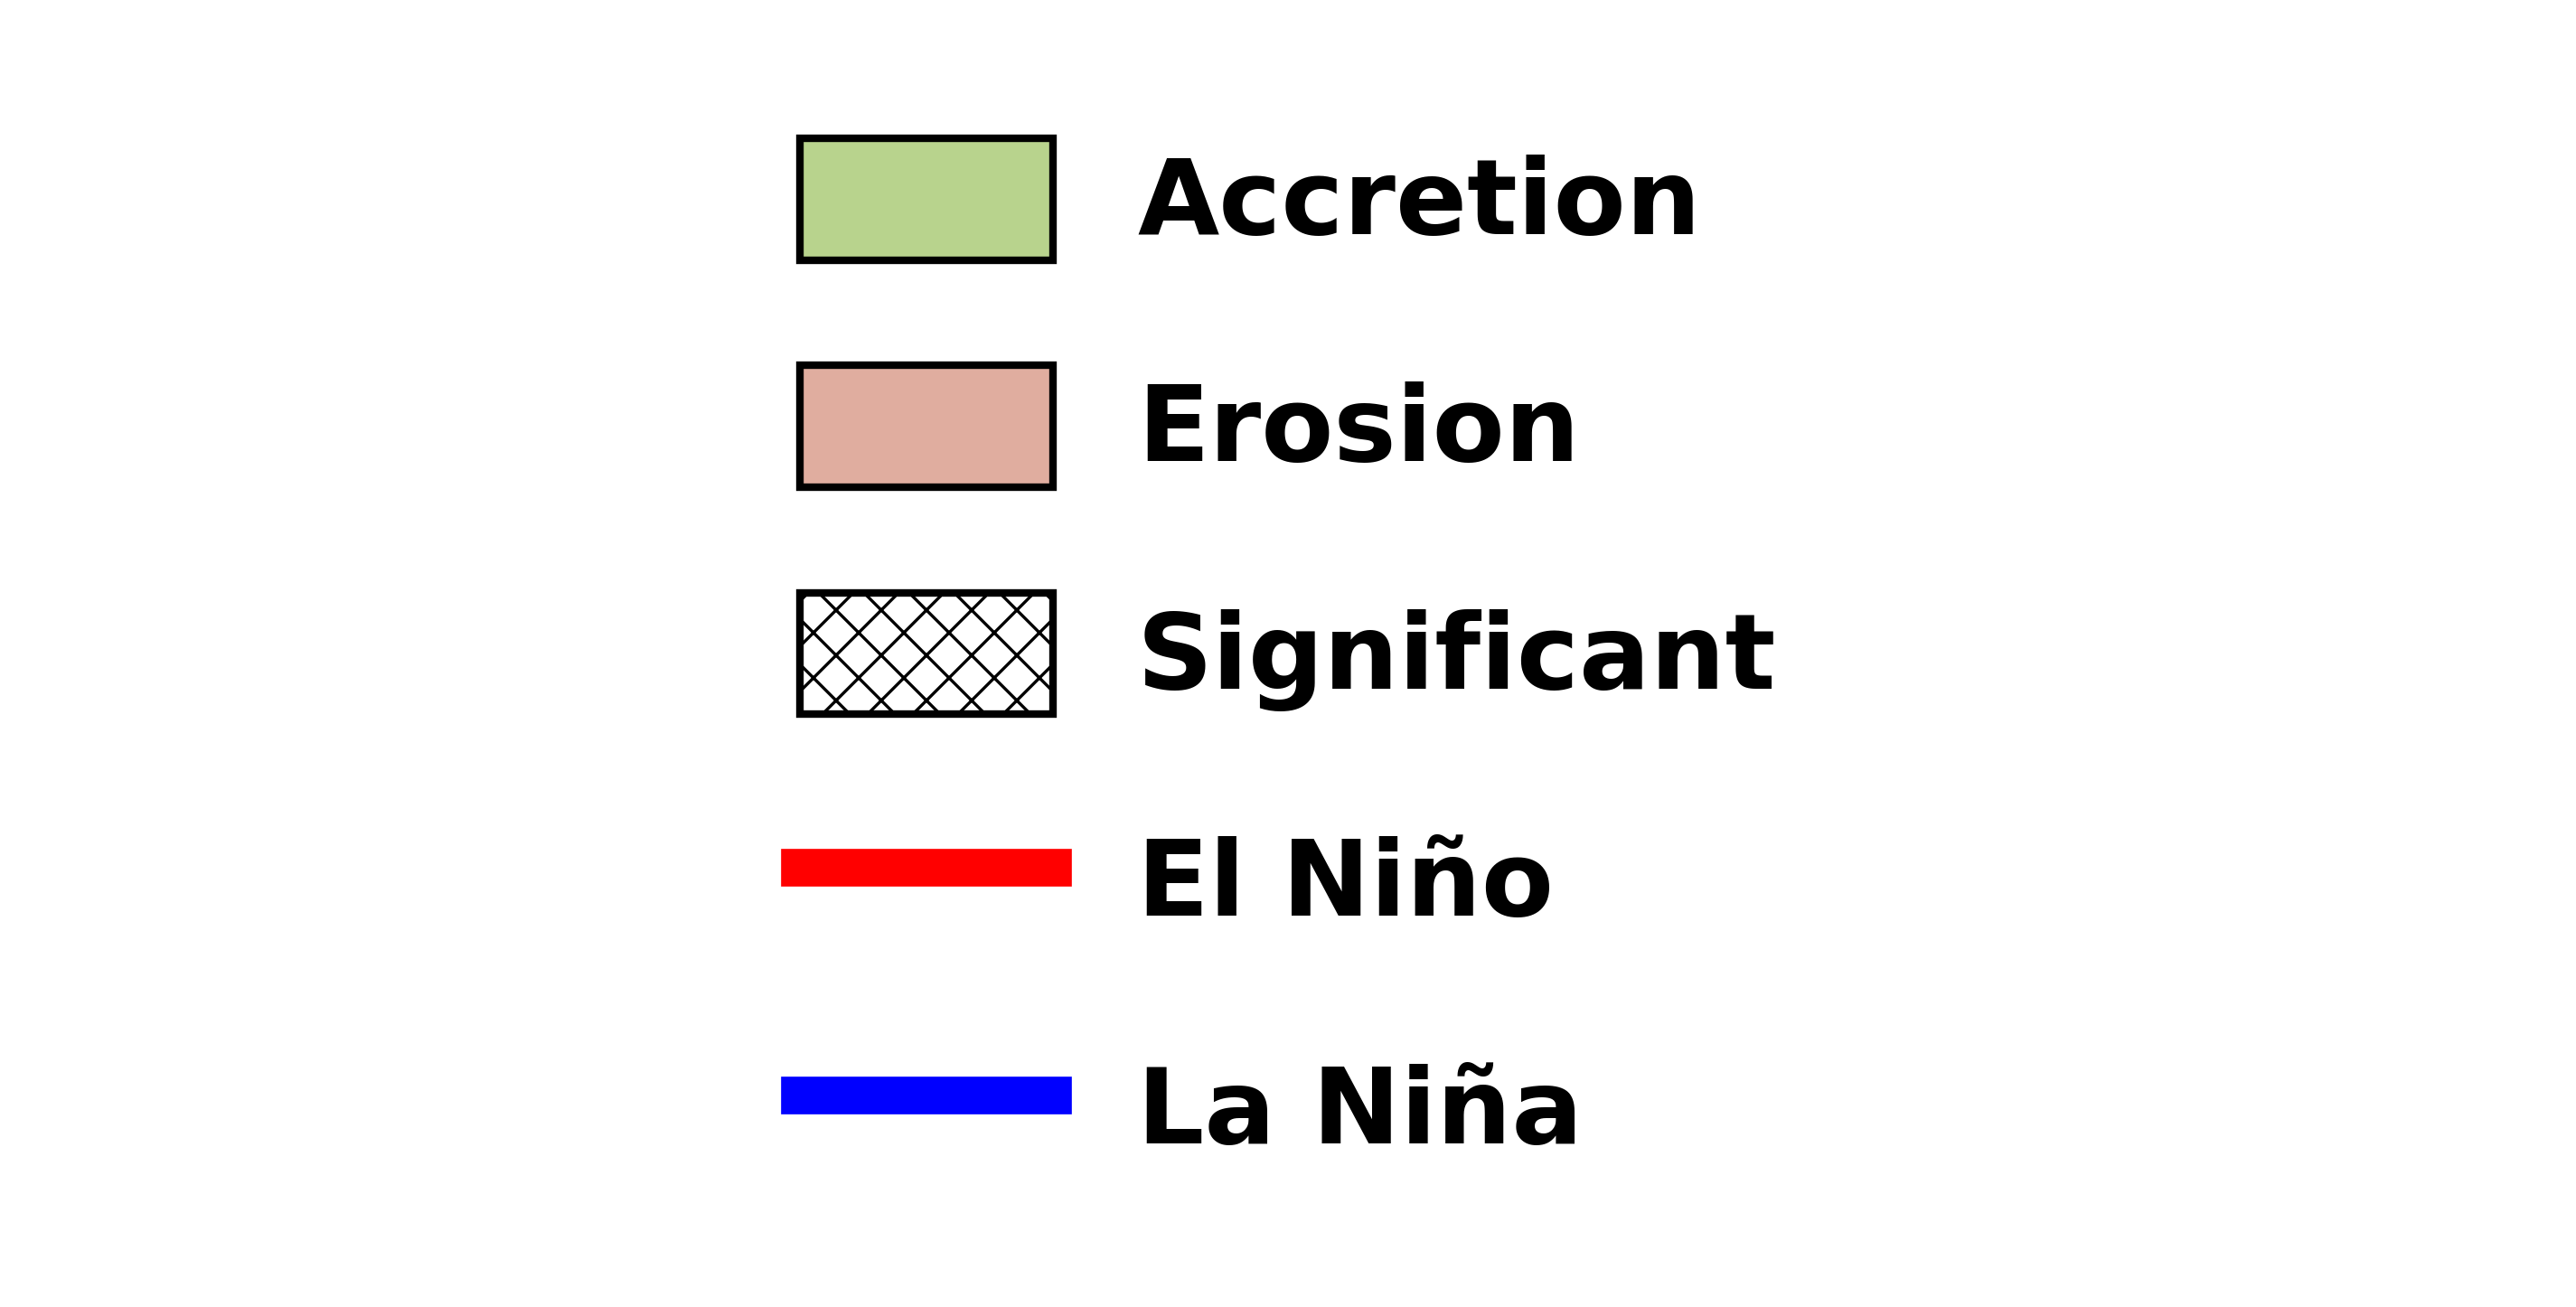

In [51]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

mpl.rcParams["hatch.linewidth"] = 0.8

accretion_color = "#b8d38d"
erosion_color = "#e0ad9f"
el_nino_color = "red"
la_nina_color = "blue"

fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

legend_handles = [
    mpatches.Patch(facecolor=accretion_color, edgecolor="black", linewidth=2, label="Accretion"),
    mpatches.Patch(facecolor=erosion_color, edgecolor="black", linewidth=2, label="Erosion"),
    mpatches.Patch(facecolor="white", edgecolor="black", hatch="xx", linewidth=2, label="Significant"),
    Line2D([0], [0], color=el_nino_color, linewidth=10, label="El Niño"),
    Line2D([0], [0], color=la_nina_color, linewidth=10, label="La Niña")
]

ax.legend(
    handles=legend_handles,
    loc="center",
    frameon=False,
    prop={"weight": "bold", "size": 28},
    handlelength=2.4,
    handleheight=1.4,
    labelspacing=1.0,   # smaller vertical spacing
    handletextpad=0.8,
    borderpad=0.2
)

ax.axis("off")

plt.gcf().savefig(os.path.join("Brian_figs", "custom_legend.png"), dpi=300, bbox_inches="tight")

plt.show()